In [8]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

from imblearn.over_sampling import SMOTE

In [9]:
df = pd.read_csv("creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [11]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

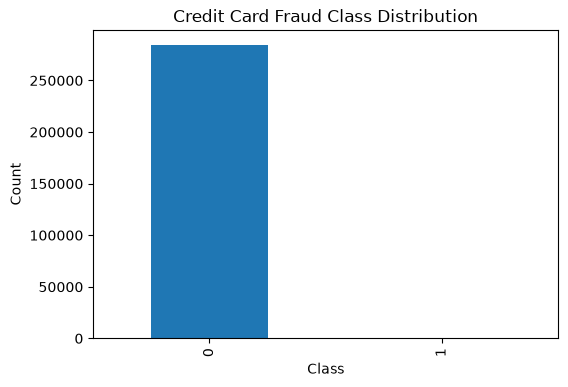

In [12]:
df["Class"].value_counts().plot(kind="bar", figsize=(6,4))

plt.title("Credit Card Fraud Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [13]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.72      0.79        98

    accuracy                           1.00     56962
   macro avg       0.93      0.86      0.89     56962
weighted avg       1.00      1.00      1.00     56962



C:\Users\PCP\Desktop\neurofive-ml-track\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [16]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print(y_train_smote.value_counts())

Class
0    227451
1    227451
Name: count, dtype: int64


In [17]:
model_smote = LogisticRegression(max_iter=1000)

model_smote.fit(X_train_smote, y_train_smote)

pred_smote = model_smote.predict(X_test)

print(classification_report(y_test, pred_smote))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.13      0.90      0.23        98

    accuracy                           0.99     56962
   macro avg       0.57      0.94      0.61     56962
weighted avg       1.00      0.99      0.99     56962



C:\Users\PCP\Desktop\neurofive-ml-track\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [18]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Before SMOTE", "After SMOTE"],
    "Accuracy": [
        accuracy_score(y_test, pred),
        accuracy_score(y_test, pred_smote)
    ]
})

comparison

,Model,Accuracy
0,Before SMOTE,0.999333
1,After SMOTE,0.989519


# Why Accuracy is Misleading

This dataset is highly imbalanced because fraudulent transactions are very rare compared to normal transactions. A model can achieve extremely high accuracy simply by predicting every transaction as normal, while failing to detect fraud. Therefore, Precision, Recall, and F1-score are much better metrics because they measure how effectively the model identifies the minority class. SMOTE helps improve the model by balancing the training data and giving the fraud class more representation during learning.

In [19]:
from sklearn.metrics import classification_report

print("===== After SMOTE =====")
print(classification_report(y_test, pred_smote))

===== After SMOTE =====
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.13      0.90      0.23        98

    accuracy                           0.99     56962
   macro avg       0.57      0.94      0.61     56962
weighted avg       1.00      0.99      0.99     56962



In [20]:
comparison = pd.DataFrame({
    "Model": ["Before SMOTE", "After SMOTE"],
    "Accuracy": [
        accuracy_score(y_test, pred),
        accuracy_score(y_test, pred_smote)
    ]
})

comparison

,Model,Accuracy
0,Before SMOTE,0.999333
1,After SMOTE,0.989519


# Week 5 - Task 1 Summary

## Handling Imbalanced Data

### Dataset
Credit Card Fraud Detection Dataset

### Technique Used
- SMOTE (Synthetic Minority Oversampling Technique)

### Results
- Trained Logistic Regression before applying SMOTE
- Applied SMOTE to balance the minority class
- Retrained the model
- Compared Precision, Recall, and F1-score before and after balancing

### Why Accuracy is Misleading

The dataset is highly imbalanced because fraudulent transactions are very rare compared to legitimate transactions. A model can achieve very high accuracy simply by predicting every transaction as legitimate, while completely missing fraud cases. Therefore, Precision, Recall, and F1-score are more reliable metrics for evaluating fraud detection models.

In [21]:
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE

# Load dataset
df = pd.read_csv("creditcard.csv")

# Features and target
X = df.drop("Class", axis=1)
y = df["Class"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Apply SMOTE
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

# Train Logistic Regression
model_smote = LogisticRegression(max_iter=1000)

model_smote.fit(
    X_train_smote,
    y_train_smote
)

# Save model
joblib.dump(model_smote, "model.pkl")

print("Model saved successfully!")

Model saved successfully!


C:\Users\PCP\Desktop\neurofive-ml-track\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [24]:
import joblib

joblib.dump(model_smote, "model.pkl")

print("Model saved successfully!")

Model saved successfully!
